In [1]:
# Import relevant libraries
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [2]:
# Read pokemon csv
df = pd.read_csv('pokemon_complete.csv')

In [3]:
# Initial view of data frame
df.head(1)

,pokedex_number,name,type_1,type_2,hp,attack,defense,sp_attack,sp_defense,speed,...,shape,egg_groups,habitat,growth_rate,capture_rate,base_happiness,genus,evolution_chain_id,flavor_text,sprite_url
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,...,quadruped,monster|plant,grassland,medium-slow,45,70,Seed Pokémon,1,A strange seed was planted on its back at birt...,https://raw.githubusercontent.com/PokeAPI/spri...


In [4]:
# Check shape of data frame
rows, columns = df.shape
print(f'There are {rows} rows and {columns} columns.')

There are 1350 rows and 31 columns.


In [5]:
# Check general data frame general info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   pokedex_number      1350 non-null   int64  
 1   name                1350 non-null   object 
 2   type_1              1350 non-null   object 
 3   type_2              765 non-null    object 
 4   hp                  1350 non-null   int64  
 5   attack              1350 non-null   int64  
 6   defense             1350 non-null   int64  
 7   sp_attack           1350 non-null   int64  
 8   sp_defense          1350 non-null   int64  
 9   speed               1350 non-null   int64  
 10  base_stat_total     1350 non-null   int64  
 11  height_m            1350 non-null   float64
 12  weight_kg           1350 non-null   float64
 13  base_experience     1302 non-null   float64
 14  abilities           1325 non-null   object 
 15  hidden_ability      988 non-null    object 
 16  genera

### Observations:
- Some columns will have to be removed during feature selection.
- They may introduce noise into the classification model.

In [6]:
# Check statistical summaries
df.select_dtypes(include='number').describe()

,pokedex_number,hp,attack,defense,sp_attack,sp_defense,speed,base_stat_total,height_m,weight_kg,base_experience,capture_rate,base_happiness,evolution_chain_id
count,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1302.000000,1350.000000,1350.000000,1350.000000
mean,2836.148148,71.671852,82.783704,76.194074,75.368148,74.095556,71.961481,452.074815,2.045259,99.171926,161.943932,89.120741,59.396296,253.156296
std,4135.531960,26.837396,32.350046,30.724283,33.989075,27.801487,30.620661,122.462374,5.325712,195.368919,82.532554,74.419310,23.239064,163.129522
min,1.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,175.000000,0.100000,0.000000,36.000000,3.000000,0.000000,1.000000
25%,338.250000,55.000000,60.000000,55.000000,50.000000,54.000000,49.000000,340.000000,0.600000,9.425000,71.000000,45.000000,50.000000,102.250000
50%,675.500000,70.000000,80.000000,70.000000,69.000000,70.000000,70.000000,475.000000,1.100000,32.700000,165.000000,55.000000,70.000000,258.000000
75%,1012.750000,85.000000,102.750000,95.000000,97.000000,90.000000,94.750000,530.000000,1.700000,85.425000,222.500000,120.000000,70.000000,392.000000
max,10325.000000,255.000000,190.000000,250.000000,216.000000,250.000000,200.000000,1125.000000,100.000000,1000.000000,608.000000,255.000000,140.000000,549.000000


In [7]:
# Create copy of data frame
df_pokemon = df.copy()

In [8]:
# Retrieve all columns
all_columns = df_pokemon.columns.to_list()

In [9]:
# Retrieve columns of importance
relevant_columns = ['type_1', 'type_2', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_stat_total',
                    'base_experience', 'capture_rate', 'is_baby' 'is_mythical']

In [10]:
# Columns to drop
for column in all_columns:
    if column not in relevant_columns:
        df_pokemon = df_pokemon.drop(columns=[column])

In [11]:
# Examine missing values after purge
df_pokemon.select_dtypes(include='number').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   hp               1350 non-null   int64  
 1   attack           1350 non-null   int64  
 2   defense          1350 non-null   int64  
 3   sp_attack        1350 non-null   int64  
 4   sp_defense       1350 non-null   int64  
 5   speed            1350 non-null   int64  
 6   base_stat_total  1350 non-null   int64  
 7   base_experience  1302 non-null   float64
 8   capture_rate     1350 non-null   int64  
dtypes: float64(1), int64(8)
memory usage: 95.1 KB


In [12]:
# Find missing values
df_pokemon.select_dtypes(include='number').isna().sum()

hp                  0
attack              0
defense             0
sp_attack           0
sp_defense          0
speed               0
base_stat_total     0
base_experience    48
capture_rate        0
dtype: int64

# Exploratory Data Analysis

### Missing Values: Base Experience

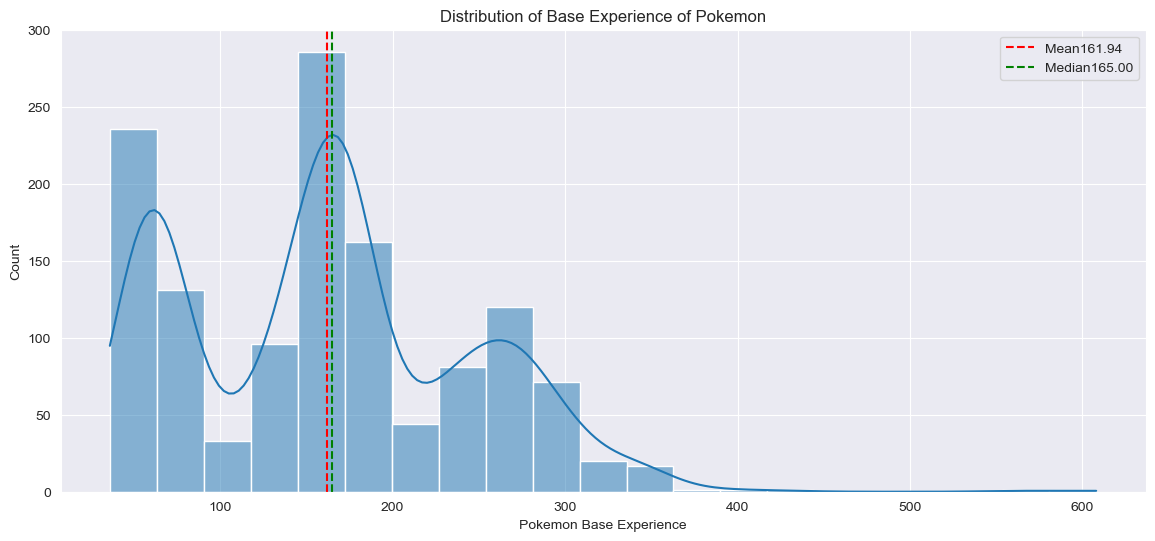

In [13]:
# Histogram to determine distribution
sns.set_style(style='darkgrid')
plt.figure(figsize=(14, 6))
sns.histplot(data=df_pokemon, x='base_experience', kde=True)
mean = df_pokemon['base_experience'].mean()
median = df_pokemon['base_experience'].median()
plt.axvline(x=mean, ls='--', c='r', label=f'Mean{mean:.2f}')
plt.axvline(x=median, ls='--', c='g', label=f'Median{median:.2f}')
plt.title('Distribution of Base Experience of Pokemon')
plt.xlabel('Pokemon Base Experience')
plt.legend()
plt.show()

### Observations:
- There could be outliers since the distribution is skewed to the right.
- Generally, median would be a better strategy to impute, but there is not much of a difference between the mean and median.

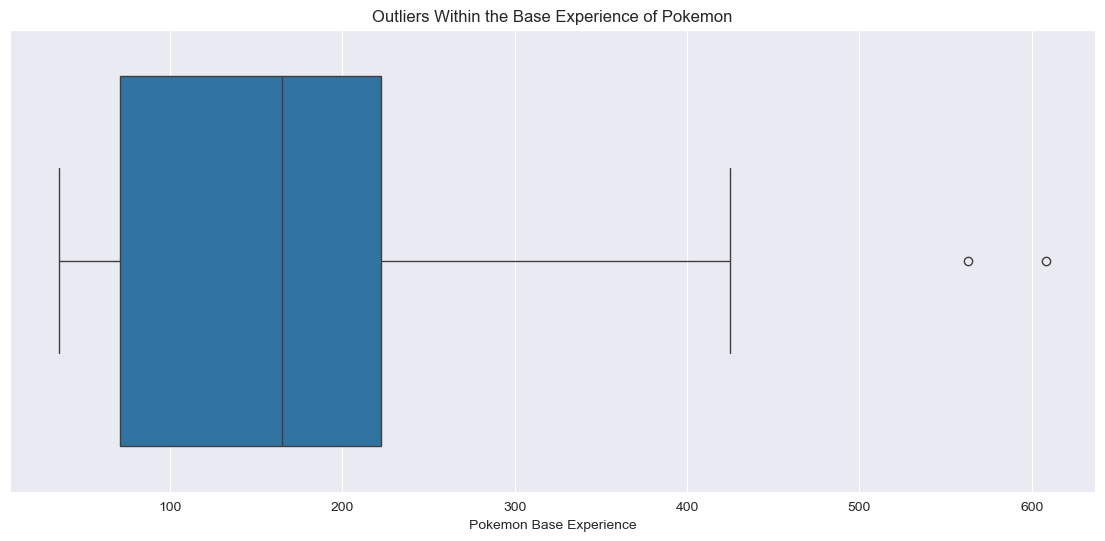

In [14]:
# Box plot to determine outliers
sns.set_style(style='darkgrid')
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_pokemon, x='base_experience')
plt.title('Outliers Within the Base Experience of Pokemon')
plt.xlabel('Pokemon Base Experience')
plt.show()

### Observations:
- Some outliers above the upper IQR bound.

### Establishing relationships using a pair plot

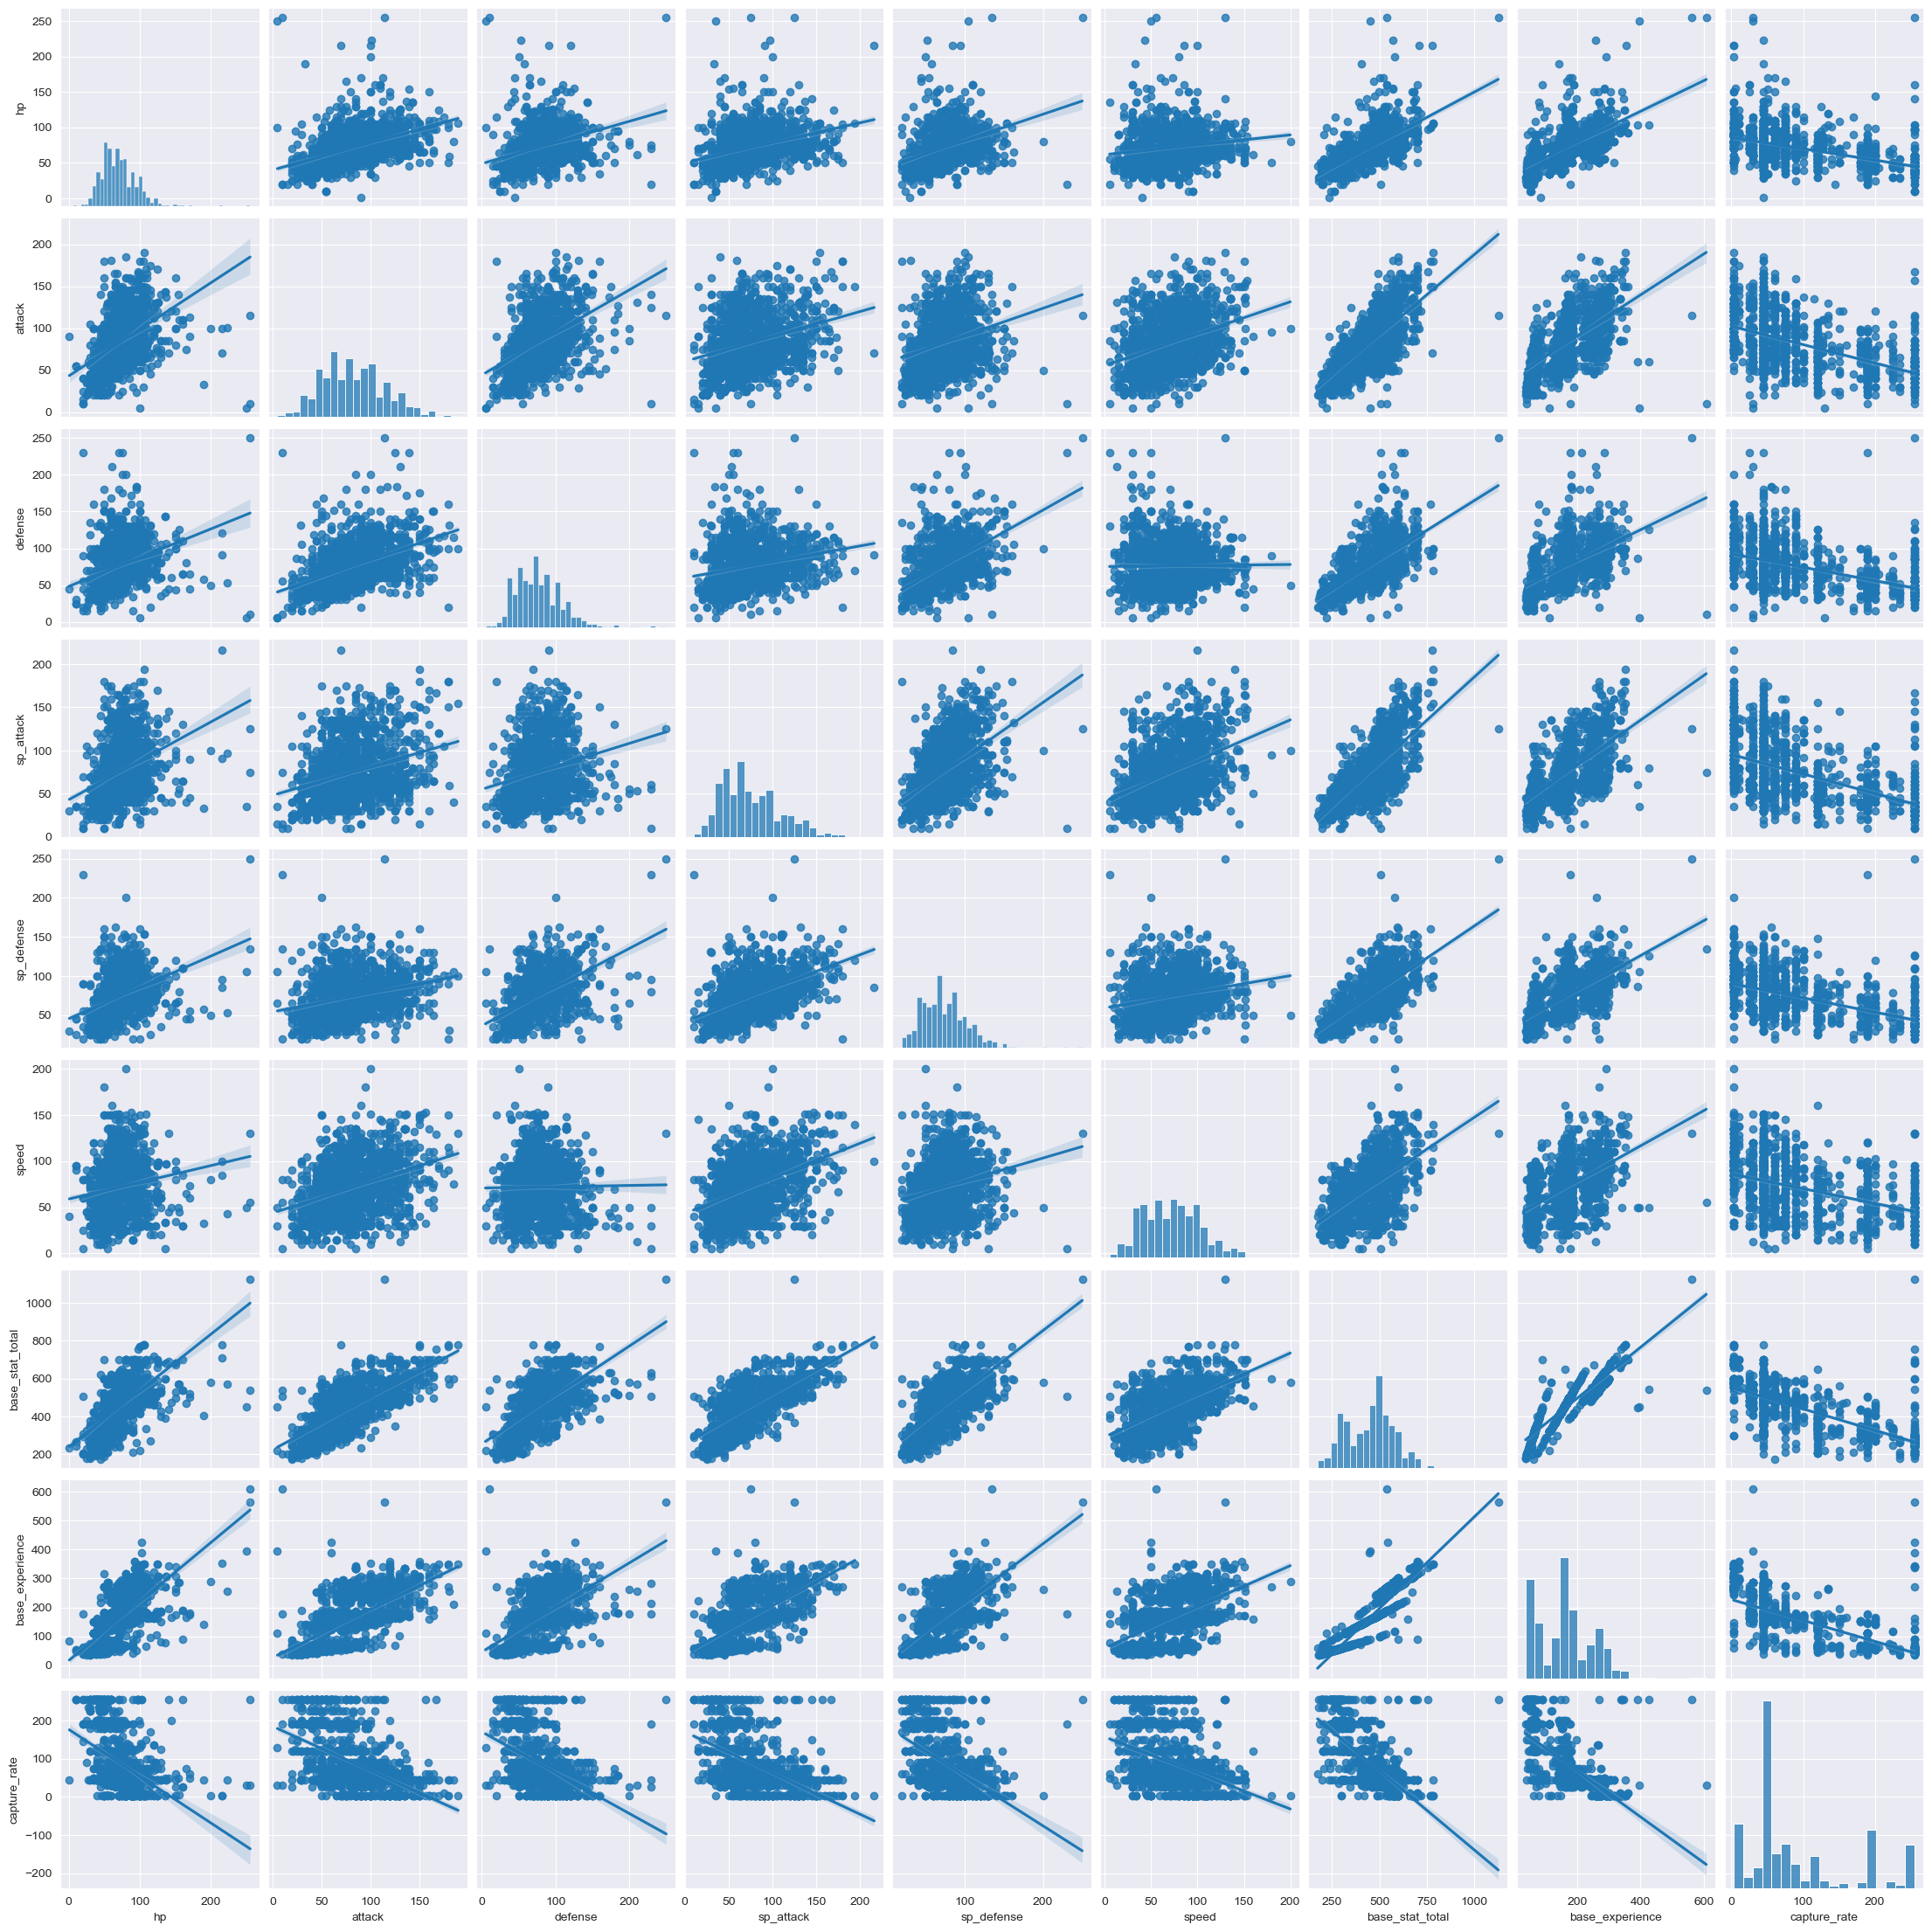

In [15]:
# Pair plot to establish relationships, with line of best fit
sns.pairplot(data=df_pokemon, kind='reg')
plt.show()

In [16]:
df_pokemon.columns.to_list()

['type_1',
 'type_2',
 'hp',
 'attack',
 'defense',
 'sp_attack',
 'sp_defense',
 'speed',
 'base_stat_total',
 'base_experience',
 'capture_rate']

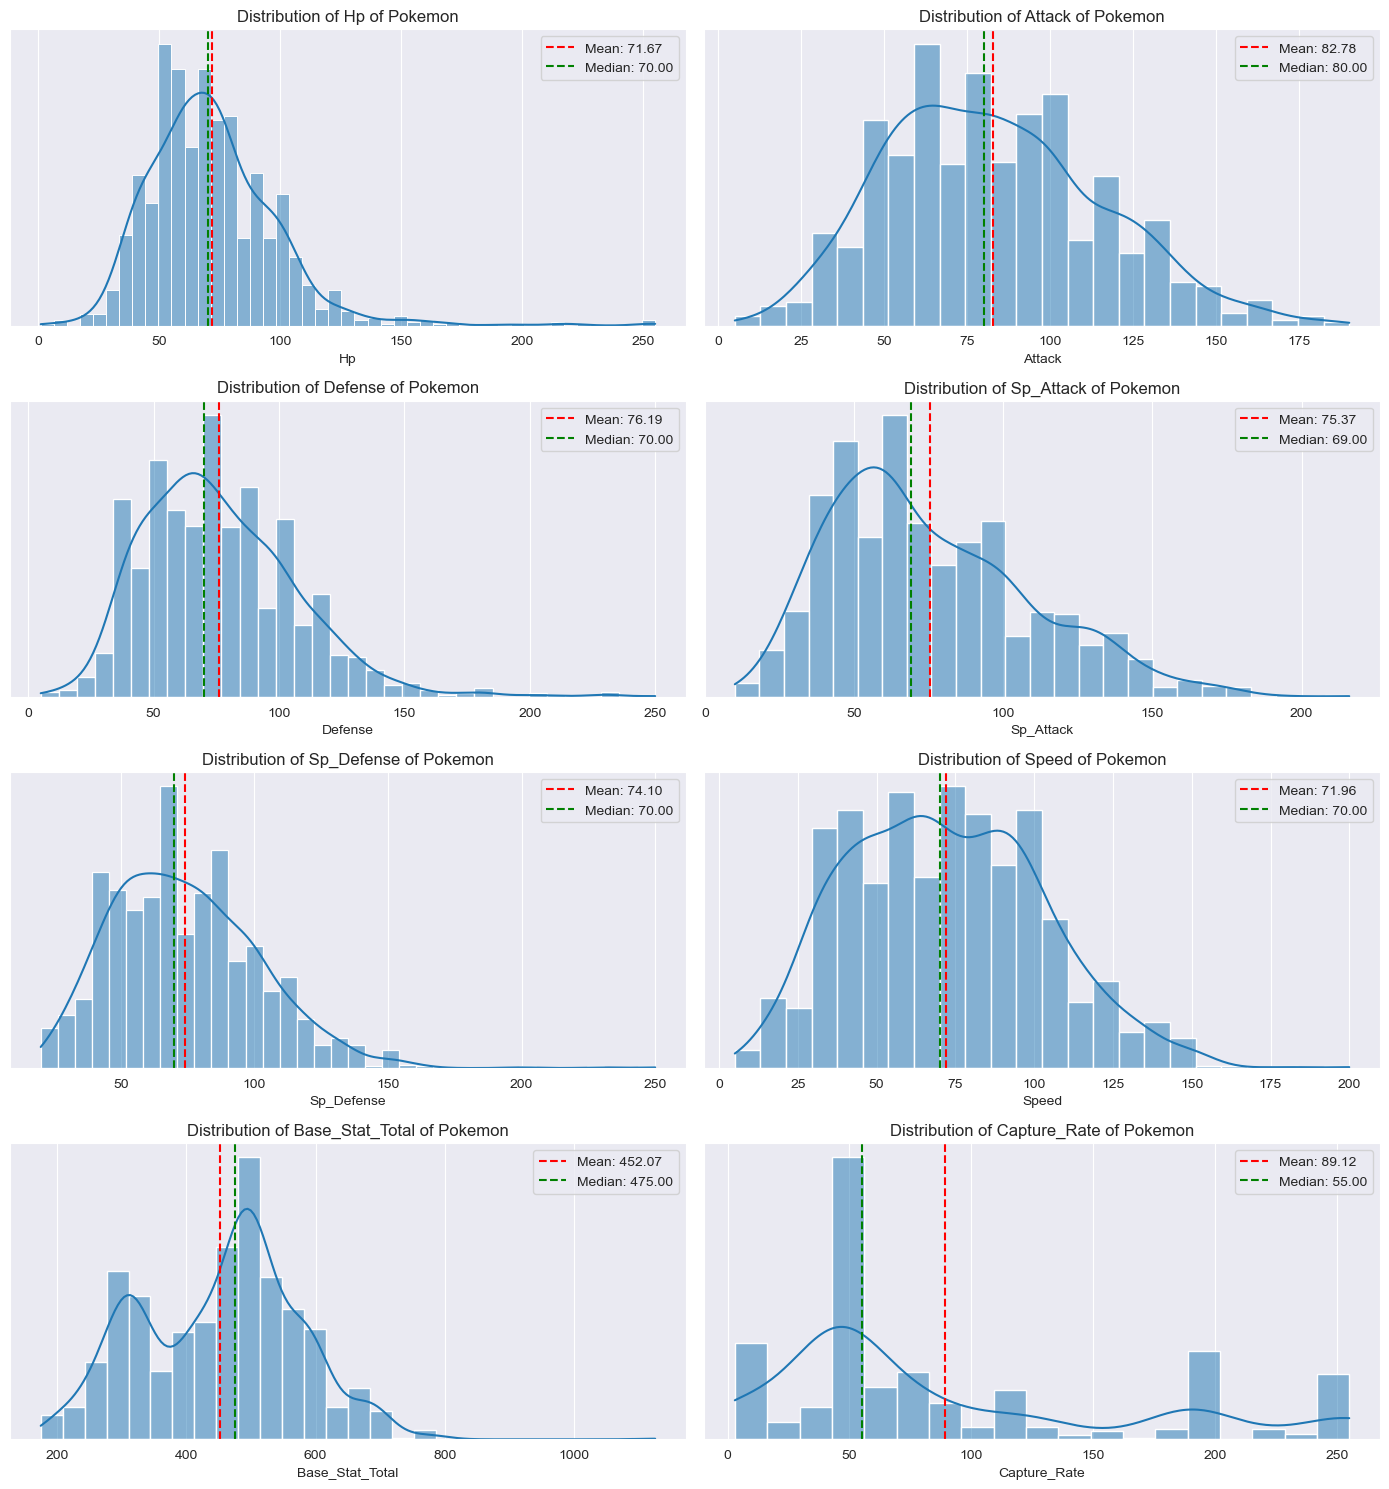

In [17]:
# Histogram to view distributions
sns.set_style(style='darkgrid')
plt.figure(figsize=(14, 15))
for index, column in enumerate(df_pokemon.select_dtypes(include='number').drop(columns='base_experience').columns.to_list(), start=1):
    plt.subplot(4, 2, index)
    sns.histplot(data=df_pokemon, x=column, kde=True)
    plt.title(f'Distribution of {column.title()} of Pokemon')
    mean = df_pokemon[column].mean()
    plt.axvline(mean, ls='--', color='r', label=f'Mean: {mean:.2f}')
    median = df_pokemon[column].median()
    plt.axvline(median, ls='--', color='g', label=f'Median: {median:.2f}')
    plt.legend()
    plt.xlabel(f'{column.title()}')
    plt.ylabel('')
    plt.yticks([])
plt.tight_layout()
plt.show()

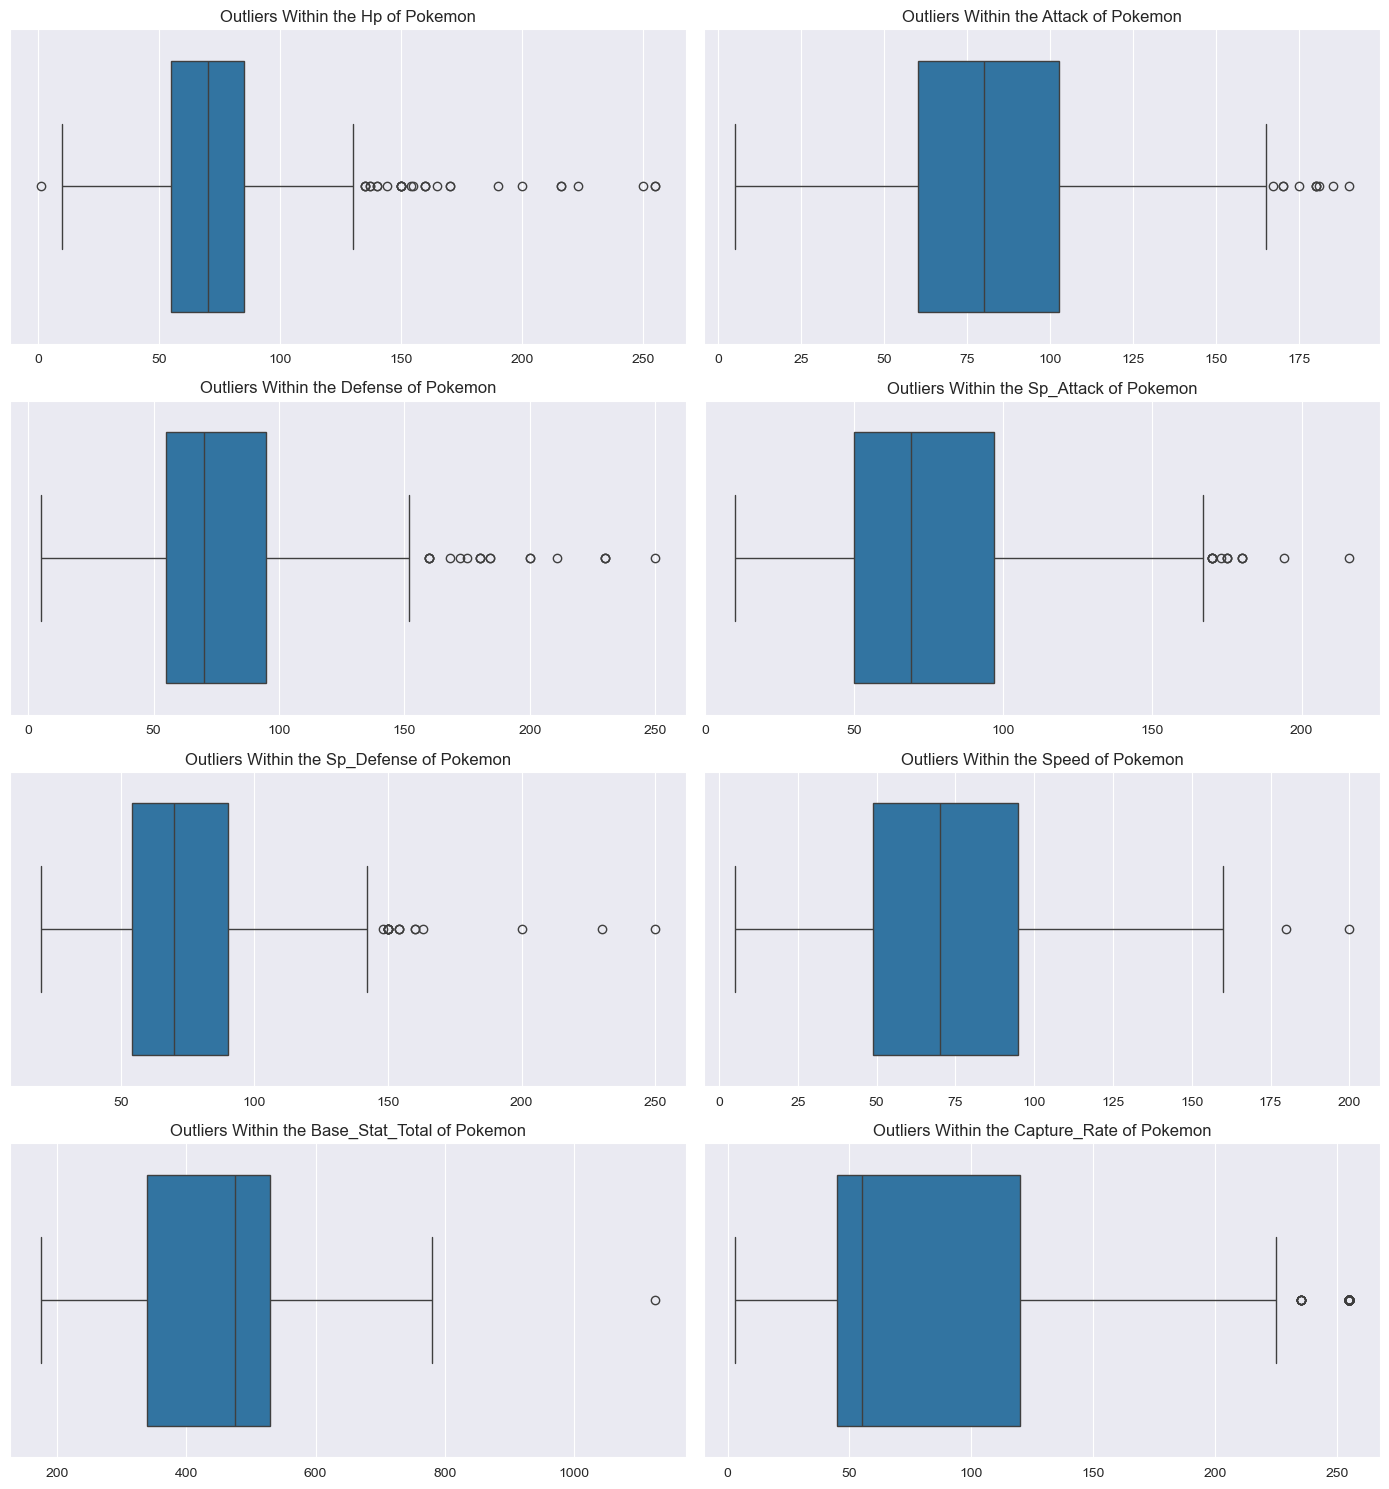

In [18]:
# Box plot to determine outliers
sns.set_style(style='darkgrid')
plt.figure(figsize=(14, 15))
for index, column in enumerate(df_pokemon.select_dtypes(include='number').drop(columns='base_experience').columns.to_list(), start=1):
    plt.subplot(4, 2, index)
    sns.boxplot(data=df_pokemon, x=column)
    plt.title(f'Outliers Within the {column.title()} of Pokemon')
    plt.xlabel('')
plt.tight_layout()
plt.show()

### Observations:
- Since legendary pokemon have higher base stat totals and greater stats in general, they are most likely the outliers.
- This however, may not be true for capture rate, since the more rare and legendary a pokemon is, the more difficult it is to catch.
- The capture rate shows, visibly, only two dark spots for pokemon with a high catch rate. It is safe to assume that these are common pokemon.

In [19]:
# Testing outlier hypothesis on catch rate
minimum_value = df_pokemon['capture_rate'].min()
Q1 = df_pokemon['capture_rate'].quantile(0.25)
Q2 = df_pokemon['capture_rate'].quantile(0.50)
Q3 = df_pokemon['capture_rate'].quantile(0.75)
maximum_value = df_pokemon['capture_rate'].max()
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
print(f'Outliers below the lower bound: {lower_bound}\n\
Outliers above the upper bound: {upper_bound}')

Outliers below the lower bound: -67.5
Outliers above the upper bound: 232.5


In [20]:
# Identify the outliers over the upper bound
df_pokemon[df_pokemon['capture_rate'] > upper_bound]

,type_1,type_2,hp,attack,defense,sp_attack,sp_defense,speed,base_stat_total,base_experience,capture_rate
9,Bug,NaN,45,30,35,20,20,45,195,39.0,255
12,Bug,Poison,40,35,30,20,20,50,195,39.0,255
15,Normal,Flying,40,45,40,35,35,56,251,50.0,255
18,Normal,NaN,30,56,35,25,35,72,253,51.0,255
20,Normal,Flying,40,60,30,31,31,70,262,52.0,255
...,...,...,...,...,...,...,...,...,...,...,...
1214,Poison,Dragon,255,115,250,125,250,130,1125,563.0,255
1224,Normal,NaN,40,45,35,40,40,90,290,58.0,255
1277,Poison,Ground,55,45,45,25,25,15,210,42.0,255
1300,Normal,NaN,95,95,110,105,110,85,600,90.0,255


### Observations:
- Few pokemon seem to have a high catch rate, but also have high base stat totals.
- These pokemon are most likely legendaries that are offered to the player as part of the plot.

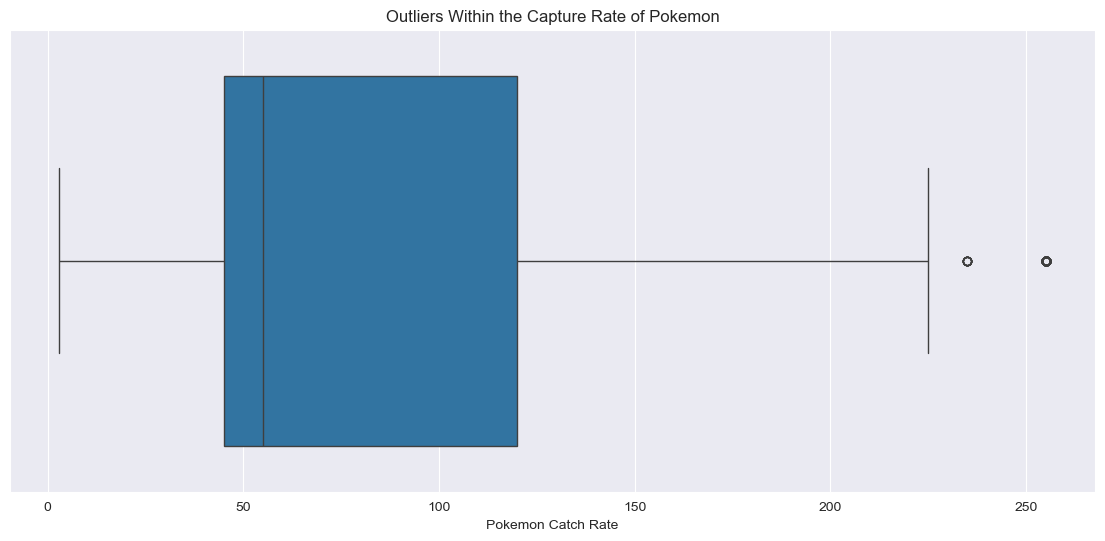

In [21]:
# Box plot to determine outliers within capture rate
sns.set_style(style='darkgrid')
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_pokemon, x='capture_rate')
plt.title('Outliers Within the Capture Rate of Pokemon')
plt.xlabel('Pokemon Catch Rate')
plt.show()

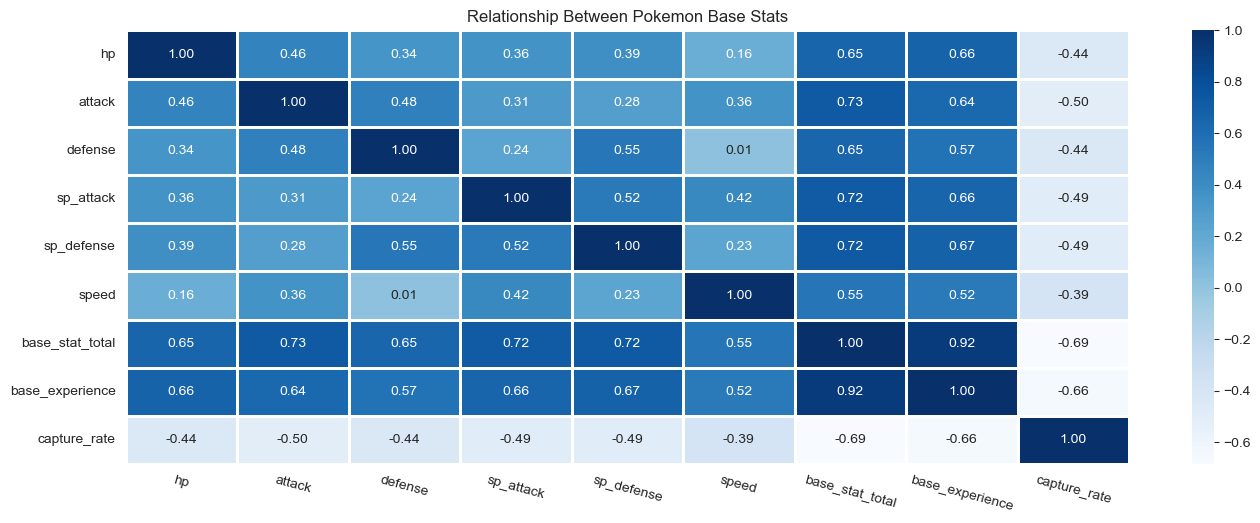

In [22]:
# Heat map to establish relationships
sns.set_style(style='darkgrid')
plt.figure(figsize=(14, 6))
sns.heatmap(data=df_pokemon.select_dtypes(include='number').corr(),
            cmap='Blues', 
            annot=True, 
            fmt='.2f', 
            linecolor='w', 
            linewidths=1)
plt.title('Relationship Between Pokemon Base Stats')
plt.tight_layout()
plt.xticks(rotation=-15)
plt.show()

### Observations:
- There may be considerations for removal based on low or negative correlation should model perform poorly

### Checking Duplicates

In [23]:
# Find sum total of duplicates
df_pokemon.duplicated().sum()

np.int64(105)

In [24]:
df_pokemon[df_pokemon.duplicated()].head(105)

,type_1,type_2,hp,attack,defense,sp_attack,sp_defense,speed,base_stat_total,base_experience,capture_rate
154,Fire,NaN,39,52,43,60,50,65,309,62.0,45
155,Fire,NaN,58,64,58,80,65,80,405,142.0,45
267,Bug,NaN,50,35,55,25,25,15,205,72.0,120
1040,Water,NaN,70,92,65,80,55,98,460,161.0,25
1049,Psychic,NaN,74,48,76,83,81,104,466,163.0,75
...,...,...,...,...,...,...,...,...,...,...,...
1294,Electric,Dragon,100,85,100,135,115,135,670,335.0,3
1295,Electric,Dragon,100,85,100,135,115,135,670,335.0,3
1342,Steel,Fairy,80,125,115,170,115,95,700,NaN,3
1347,Dragon,Water,68,65,90,135,125,92,575,NaN,100


### Observation:
- Some entries are variants of a pokemon and carry similar stats information, while others do not.
- Pokemon like Pikachu have several variants, and this could introduce bias into the model
- A decision to use something like `df_pokemon.drop_duplicates(df_pokemon.iloc[1104:1110, :])` may have to be considered

### Removing Megas, Regional Forms, and Tera

In [25]:
# Create another copy
df_pokemon_main = df.copy()

In [26]:
# Find mega evolutions
mega_condition = df_pokemon_main['name'].str.contains('-Mega')

In [27]:
# Drops all rows with mega evolutions
df_pokemon_main.drop(df_pokemon_main[mega_condition].index, inplace=True)

In [28]:
# Find tera pokemon
df_pokemon_main[df_pokemon_main['name'].str.contains('Tera')].index

Index([1023, 1300, 1301], dtype='int64')

In [29]:
# Drop other forms of Terapagos
df_pokemon_main.drop([1300, 1301], inplace=True)

In [30]:
# Drop regional variants
df_pokemon_main.drop_duplicates(inplace=True)

In [31]:
# Fill type 2 missing values
df_pokemon_main['type_2'] = df_pokemon_main['type_2'].fillna(value='None')

### Feature Selection

In [32]:
# Select features
X = df_pokemon_main[['type_1', 'type_2', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed',
                     'base_stat_total', 'base_experience', 'capture_rate', 'is_baby', 'is_mythical']]
y = df_pokemon_main['is_legendary']

In [33]:
legendary_status = y.value_counts().reset_index()

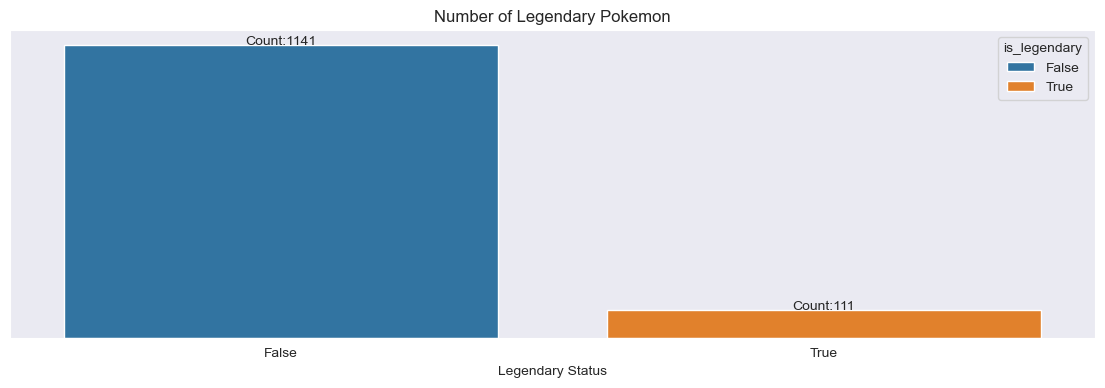

In [34]:
# Visualise target
plt.figure(figsize=(14, 4))
sns.set_style(style='darkgrid')
sns.barplot(data=legendary_status, y='count', x='is_legendary', hue='is_legendary')
for index, item in enumerate(y.value_counts(ascending=False), start=0):
    plt.text(index, item, f'Count:{item}', ha='center')
plt.title('Number of Legendary Pokemon')
plt.ylabel('')
plt.yticks([])
plt.xlabel('Legendary Status')
plt.show()

### Observations:
- Target is imbalanced. Oversampling will have to be considered.

In [35]:
# Extracting feature list
numerical_columns = X.select_dtypes(include='number').columns.to_list()
numerical_features = X.select_dtypes(include='number')
categorical_columns = X.select_dtypes(include='object').columns.to_list()
categorical_features = X.select_dtypes(include='object')

In [36]:
# Identify categorical features that require imputing
numerical_features.isna().sum()

hp                 0
attack             0
defense            0
sp_attack          0
sp_defense         0
speed              0
base_stat_total    0
base_experience    0
capture_rate       0
dtype: int64

In [37]:
# Identify categorical features that require imputing
categorical_features.isna().sum()

type_1    0
type_2    0
dtype: int64

In [38]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Model Selection
Some models will be tested to identify which has the best recall rate.

Models to be used:
1. Logistic Regression
2. K-Nearest Neighbours
3. Support Vector Machine
4. Random Forest
5. Naive Bayes
6. Decision Tree

### Pipeline Creation and Model Options

In [39]:
# Initialize recall scores list
recall_scores = []

# Names of models    
model_names = ['Logistic Regression', 
               'K Neighbors',
               'SVC',
               'Random Forest',
               'Decision Tree']

# Initialize classification reports
classification_reports = []
confusion_matrices = []

In [40]:
# Define a function that will run selected models
def learn_predict():
    '''
    This function creates a pipeline and runs a selected number of classification models.
    '''
    
    models = [LogisticRegression(), 
              KNeighborsClassifier(), 
              SVC(), 
              RandomForestClassifier(),
              DecisionTreeClassifier()]
    
    numerical_steps = Pipeline([('scaling', StandardScaler())])
    categorical_steps = Pipeline([('encoding', OneHotEncoder(drop='first'))])
    preprocessor = ColumnTransformer([('numerical', numerical_steps, numerical_columns), ('categorical', categorical_steps, categorical_columns)])
    
    for model in models:
        chosen_model = Pipeline([('preprocessing', preprocessor), ('smote', SMOTE(random_state=42)), ('classifier', model)])
        # Fit the model with the train data
        chosen_model.fit(X_train, y_train)
        # Predict using the model
        y_pred = chosen_model.predict(X_test)
        # Retrieving the classification report
        cr = classification_report(y_true=y_test, y_pred=y_pred)
        classification_reports.append(cr)
        # Retrieving the confusion matrix
        cm = confusion_matrix(y_true=y_test, y_pred=y_pred)
        confusion_matrices.append(cm)
        
        # Measure by recall
        rs = recall_score(y_true=y_test, y_pred=y_pred)
        recall_scores.append(rs)

In [41]:
# Calling the prediction function
learn_predict()

In [42]:
# Define a function that creates a data frame based on recall scores and returns a bar plot
def create_score_dataframe_plot():
    '''
    This function creates a dataframe from the extracted recall scores of each model.
    '''
    # Create dictionary to store recall scores
    recall_dict = {'Model_Names': model_names,
                   'Recall_Scores': recall_scores}
    
    # Create data frame with 
    df_recall = pd.DataFrame(recall_dict)

    # Assign new percentage column
    df_recall['Percentages'] = df_recall['Recall_Scores'].apply(lambda x: x*100)

    # Export score database
    df_recall.to_csv('df_recall_scores.csv', index=False)

    # Visualize the recall scores
    plt.figure(figsize=(14, 5))
    sns.set_style(style='darkgrid')
    sns.barplot(data=df_recall, x='Model_Names', y='Percentages', hue='Model_Names')
    
    for index, value in enumerate(df_recall['Percentages'].to_list()):
        plt.text(index, value, f'{value:.2f}', ha='center')
    
    plt.title('Comparing Model Accuracy Using Recall')
    plt.yticks([])
    plt.ylabel('')
    plt.xlabel('Models')
    plt.show()

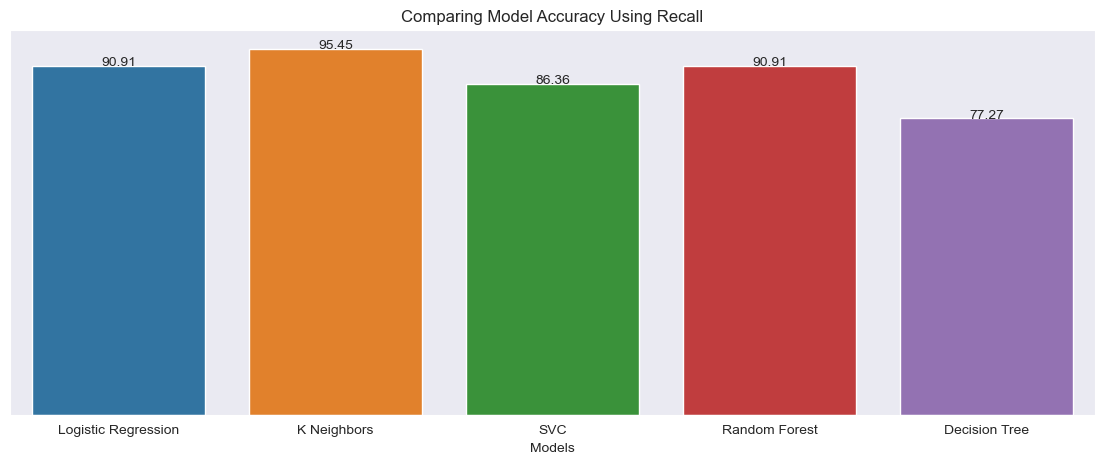

In [43]:
create_score_dataframe_plot()

In [44]:
# Define a function that stores the recall scores and confusion matrices, with intent to retrieve the best model
def best_model():
    data_1 = dict(zip(model_names, recall_scores))
    max_key = max(data_1, key=data_1.get)
    best_score = data_1.get(max_key)

    data_2 = dict(zip(model_names, confusion_matrices))
    cm = data_2.get(max_key)    
    print(f'The best model is {max_key} with a recall score of {best_score*100:.2f}.')
    
    sns.set_style(style='darkgrid')
    sns.heatmap(data=cm, annot=True, fmt='', cmap='Blues', linecolor='w', linewidths=1)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix for {max_key}')
    plt.show()

The best model is K Neighbors with a recall score of 95.45.


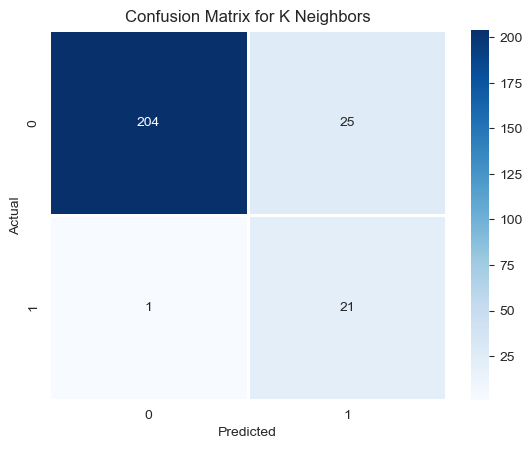

In [45]:
best_model()